# XAI skalibrowanego modelu v2
Próbki losowane warstwowo. Średnie bezwzględne SHAP agregowane według tekstu tokenu, nie jego pozycji. Analiza opisowa nie służy zmianom modelu po obejrzeniu testu.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import os
import sys

root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(root))
# Ustawić przed importem src.config; istniejące zmienne środowiskowe mają pierwszeństwo.
os.environ.setdefault("PHISHING_RUN_ID", "thesis_v2_macos27")
os.environ.setdefault("PHISHING_SEED", "42")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

from src.config import RESULTS_DIR, SAVED_MODELS_DIR, RUN_ID, RANDOM_STATE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "font.size": 11})
figure_dir = RESULTS_DIR / "notebook_figures"
figure_dir.mkdir(parents=True, exist_ok=True)
print(f"Przebieg: {RUN_ID}; seed: {RANDOM_STATE}")
print(f"Wykonano (UTC): {datetime.now(timezone.utc).isoformat(timespec='seconds')}")


Przebieg: thesis_v2_macos27; seed: 42
Wykonano (UTC): 2026-09-16T17:21:34+00:00


In [2]:
import shap
from src.evaluation.explainer import PhishingExplainer
from src.evaluation.evaluate import load_final_predictions

frame = load_final_predictions()
frame = frame[frame.model == "herbert-base"]
samples = frame.groupby("Is_Phishing", group_keys=False).sample(n=5, random_state=42)
explainer = PhishingExplainer(str(SAVED_MODELS_DIR / "herbert-base"))
contributions = []

try:
    for row in samples.itertuples():
        values = explainer.get_explanation(row.Text)

        for token, impact in zip(values.data[0], values.values[0, :, 1]):
            contributions.append({"token": str(token).strip(), "absolute_impact": abs(float(impact)), "Record_ID": row.Record_ID})

        shap.plots.text(values[0, :, 1])

finally:
    explainer.close()

importance = pd.DataFrame(contributions).groupby("token").absolute_impact.agg(["mean", "count"]).sort_values("mean", ascending=False)
importance.to_csv(RESULTS_DIR / "shap_token_importance.csv")
display(importance.head(20))


/Users/7312/Desktop/Repositories/phishing-transformer-detection/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,mean,count
token,,
TY,0.113578,10
Powi,0.113327,1
Masz,0.110726,1
Poczta,0.089031,1
nowa,0.081468,2
eu,0.081324,1
les,0.078603,1
PE,0.072377,10
com,0.072210,2


## Wpływ tokenów w analizowanej próbce
Średnia wartość bezwzględna SHAP dla wystąpień tokenu w 10 wiadomościach (po 5 na klasę). Wykres opisuje tę próbkę; nie jest globalnym rankingiem cech modelu.

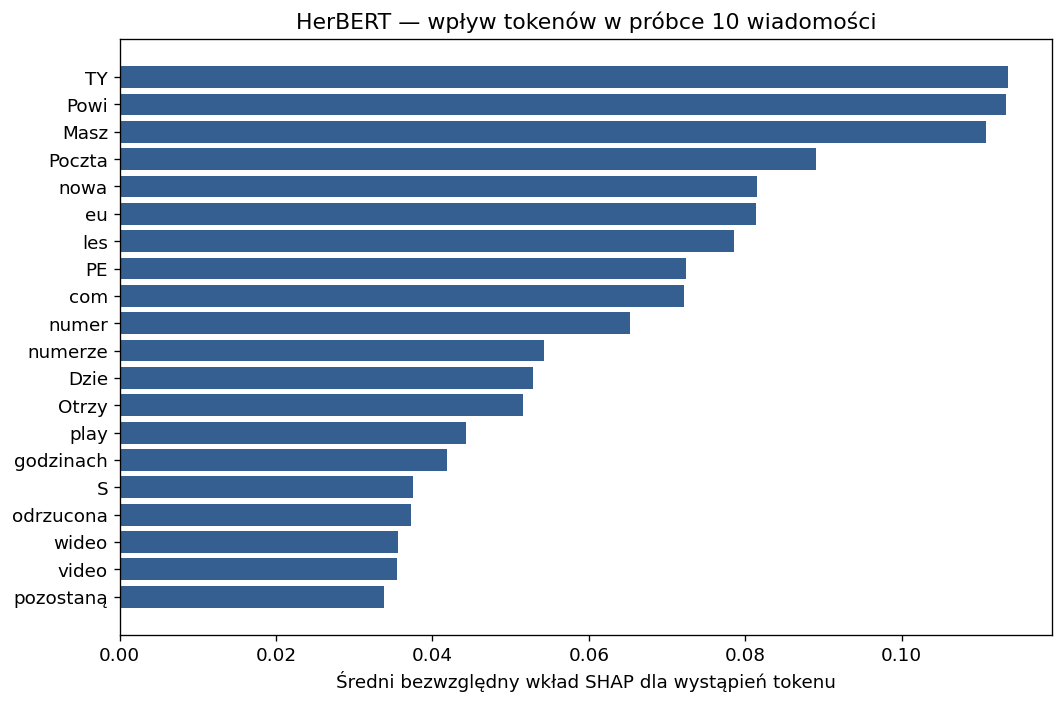

In [3]:
top = importance.loc[importance.index.str.len() > 0].head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top.index, top["mean"], color="#365f91")
ax.set(xlabel="Średni bezwzględny wkład SHAP dla wystąpień tokenu",
       title="HerBERT — wpływ tokenów w próbce 10 wiadomości")
fig.tight_layout()
for extension in ("png", "pdf"):
    fig.savefig(figure_dir / f"herbert_shap_sample_tokens.{extension}", bbox_inches="tight")
plt.show()
plt.close(fig)
